In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from matplotlib.ticker import FuncFormatter
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)


df = pd.read_csv("data_clean/analysis_ready.csv")

df.head()

,fips_code,state,county,population,metro_status,poverty_pct,bachelors_pct,median_income,2023_unemployment_rate,2024_unemployment_rate,2023_violent_crime,2024_violent_crime,2023_property_crime,2024_property_crime,avg_unemployment_rate,violent_rate_2023,violent_rate_2024,avg_violent_crime_rate,property_rate_2023,property_rate_2024,avg_property_crime_rate,metro_dummy
0,1001,Alabama,Autauga,59285.0,Metro,10.7,28.3,69841.0,2.1,2.6,47.0,54.0,220.0,221.0,2.35,79.278064,91.085435,85.181749,371.088808,372.775576,371.932192,1
1,1003,Alabama,Baldwin,239945.0,Metro,10.5,32.8,75019.0,2.2,2.7,108.0,137.0,196.0,170.0,2.45,45.010315,57.096418,51.053366,81.685386,70.849570,76.267478,1
2,1005,Alabama,Barbour,24757.0,Non-Metro,21.9,11.5,44290.0,3.9,4.0,8.0,11.0,26.0,15.0,3.95,32.314093,44.431878,38.372985,105.020802,60.588924,82.804863,0
3,1007,Alabama,Bibb,22152.0,Metro,20.5,11.5,51215.0,2.4,2.9,25.0,34.0,82.0,78.0,2.65,112.856627,153.485013,133.170820,370.169736,352.112676,361.141206,1
4,1009,Alabama,Blount,59292.0,Metro,14.1,15.6,61096.0,2.0,2.6,111.0,82.0,376.0,298.0,2.30,187.209067,138.298590,162.753829,634.149632,502.597315,568.373474,1


## 1. Data Overview

This analysis examines the relationship between county-level socioeconomic characteristics and crime rates across the United States. The dataset combines county-level crime data from the FBI Crime Data Explorer with socioeconomic data from the U.S. Census Bureau and unemployment data from the Bureau of Labor Statistics. Before beginning the statistical analysis, the dataset is reviewed for completeness and prepared for analysis.

In [3]:
# Basic information about the dataset

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.info()

Rows: 2172
Columns: 22
<class 'pandas.DataFrame'>
RangeIndex: 2172 entries, 0 to 2171
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   fips_code                2172 non-null   int64  
 1   state                    2172 non-null   str    
 2   county                   2172 non-null   str    
 3   population               2172 non-null   float64
 4   metro_status             2172 non-null   str    
 5   poverty_pct              2172 non-null   float64
 6   bachelors_pct            2172 non-null   float64
 7   median_income            2172 non-null   float64
 8   2023_unemployment_rate   2172 non-null   float64
 9   2024_unemployment_rate   2172 non-null   float64
 10  2023_violent_crime       2172 non-null   float64
 11  2024_violent_crime       2172 non-null   float64
 12  2023_property_crime      2172 non-null   float64
 13  2024_property_crime      2172 non-null   float64
 14  avg_unemploy

### 1.1 Remove counties with populations under 1,000. 

Very small populations can produce unstable per-capita crime rate numbers that are not representative of broader county-level trends. Removing these counties reduces the influence of extreme crime rates that can occur when relatively few crimes are divided by very small populations.

In [5]:
original_counties = len(df)

MIN_POPULATION = 1000

df = df[df["population"] >= MIN_POPULATION].copy()

print(f"Original counties: {original_counties}")
print(f"Remaining counties: {len(df)}")
print(f"Removed counties: {original_counties - len(df)}")

Original counties: 2172
Remaining counties: 2162
Removed counties: 10


In [6]:
# Check data quality

print("Missing Values")
display(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

Missing Values


fips_code                  0
state                      0
county                     0
population                 0
metro_status               0
poverty_pct                0
bachelors_pct              0
median_income              0
2023_unemployment_rate     0
2024_unemployment_rate     0
2023_violent_crime         0
2024_violent_crime         0
2023_property_crime        0
2024_property_crime        0
avg_unemployment_rate      0
violent_rate_2023          0
violent_rate_2024          0
avg_violent_crime_rate     0
property_rate_2023         0
property_rate_2024         0
avg_property_crime_rate    0
metro_dummy                0
dtype: int64


Duplicate Rows
0


## 2. Descriptive Statistics

Descriptive statistics provide an initial summary of the variables included in the analysis. Reviewing measures such as the mean, standard deviation, minimum, and maximum values helps identify the overall distribution and variability of each variable before examining relationships among them.

In [8]:
analysis_cols = [
    "poverty_pct",
    "bachelors_pct",
    "median_income",
    "avg_unemployment_rate",
    "avg_violent_crime_rate",
    "avg_property_crime_rate"
]

df[analysis_cols].describe().round(2)

,poverty_pct,bachelors_pct,median_income,avg_unemployment_rate,avg_violent_crime_rate,avg_property_crime_rate
count,2162.00,2162.00,2162.00,2162.00,2162.00,2162.00
mean,14.16,24.26,66647.86,3.80,103.68,388.50
std,5.69,10.01,17146.84,1.19,110.33,354.19
min,2.70,6.20,28321.00,1.50,0.00,0.00
25%,10.00,17.10,55501.00,3.05,33.73,159.01
50%,13.30,21.60,64496.50,3.60,73.00,302.40
75%,17.40,29.30,74181.00,4.30,135.65,520.20
max,45.20,65.20,178707.00,18.00,1397.25,4579.60


The descriptive statistics indicate substantial variation among U.S. counties for both crime rates and socioeconomic characteristics. Several variables exhibit wide ranges and potential outliers, making visual inspection an important next step before conducting statistical analyses.

In [10]:
# How many Metro vs Non-Metro counties

df["metro_status"].value_counts()

metro_status
Non-Metro    1290
Metro         872
Name: count, dtype: int64

## 3. Exploratory Data Analysis

Exploratory data analysis (EDA) was performed to better understand the distributions of the variables, identify potential outliers, and visually examine relationships between socioeconomic variables and crime rates prior to formal statistical testing.

### 3.1 Histograms

The histograms below illustrate the distribution of each variable included in the analysis. These plots were reviewed to identify skewness, unusual observations, and departures from normality that could influence later statistical analyses.

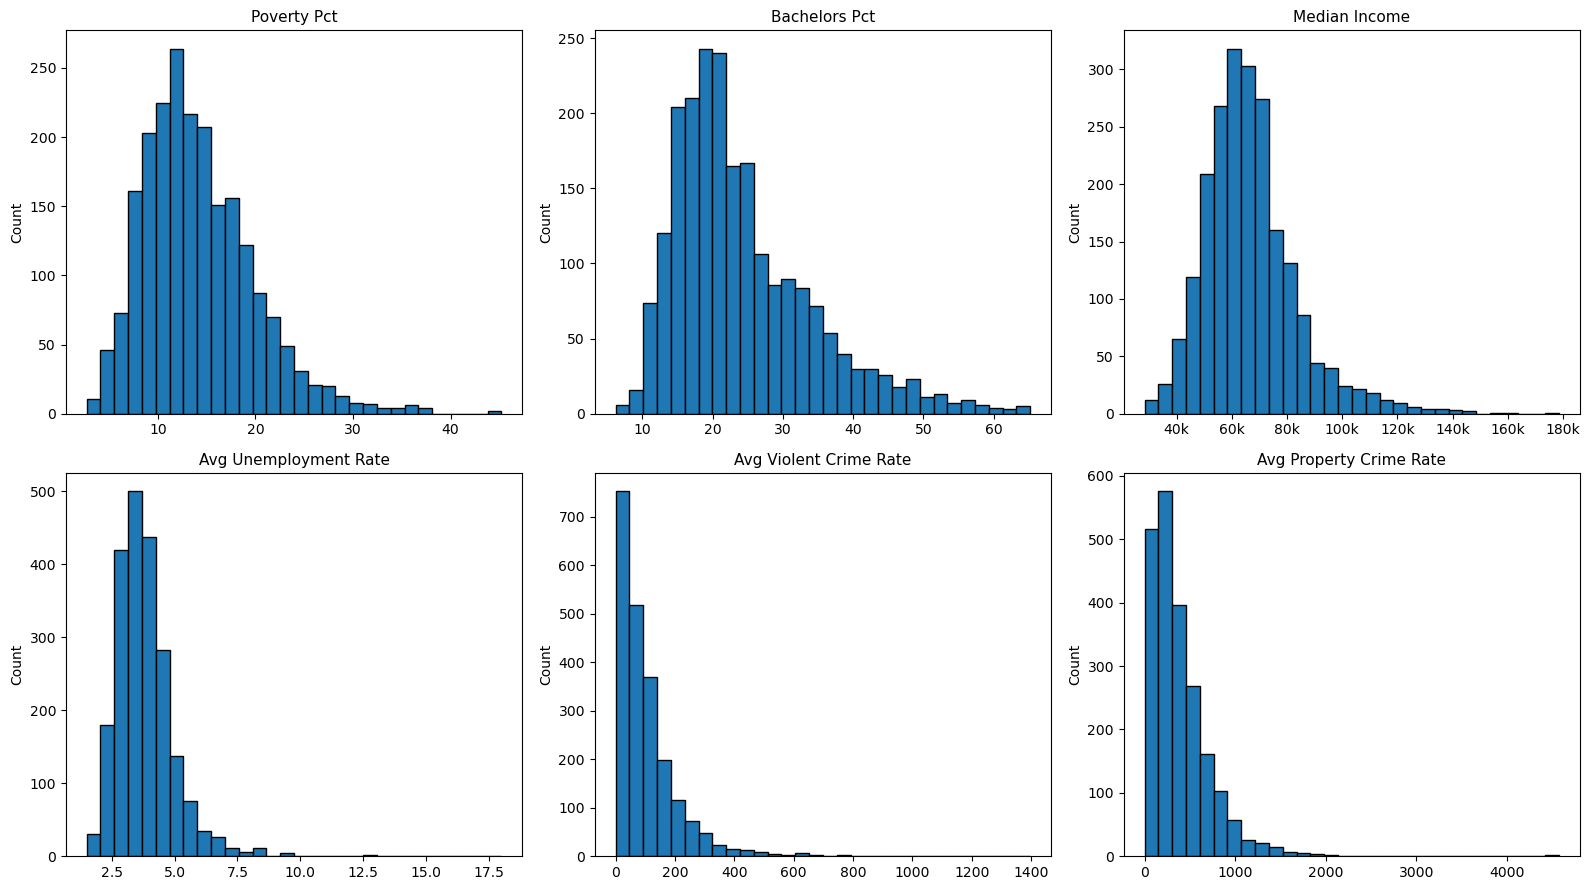

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flatten(), analysis_cols):
    ax.hist(df[col], bins=30, edgecolor="black")
    ax.set_title(col.replace("_", " ").title(), fontsize=11)
    ax.set_ylabel("Count")

    # Format median income axis as thousands
    if col == "median_income":
        ax.xaxis.set_major_formatter(
            FuncFormatter(lambda x, pos: f"{int(x/1000)}k")
        )

plt.tight_layout()
plt.show()

Most variables exhibit moderate right-skew, particularly the crime rate variables. Several variables also contain high-value observations, although these represent legitimate counties rather than apparent data errors. Because the sample size is large, these distributions were considered acceptable for the planned analyses.

### 3.2 Boxplots

Boxplots provide another view of each variable by highlighting the median, interquartile range, and potential outliers. These visualizations were used to identify counties with unusually high or low values and to determine whether any observations warranted further investigation.

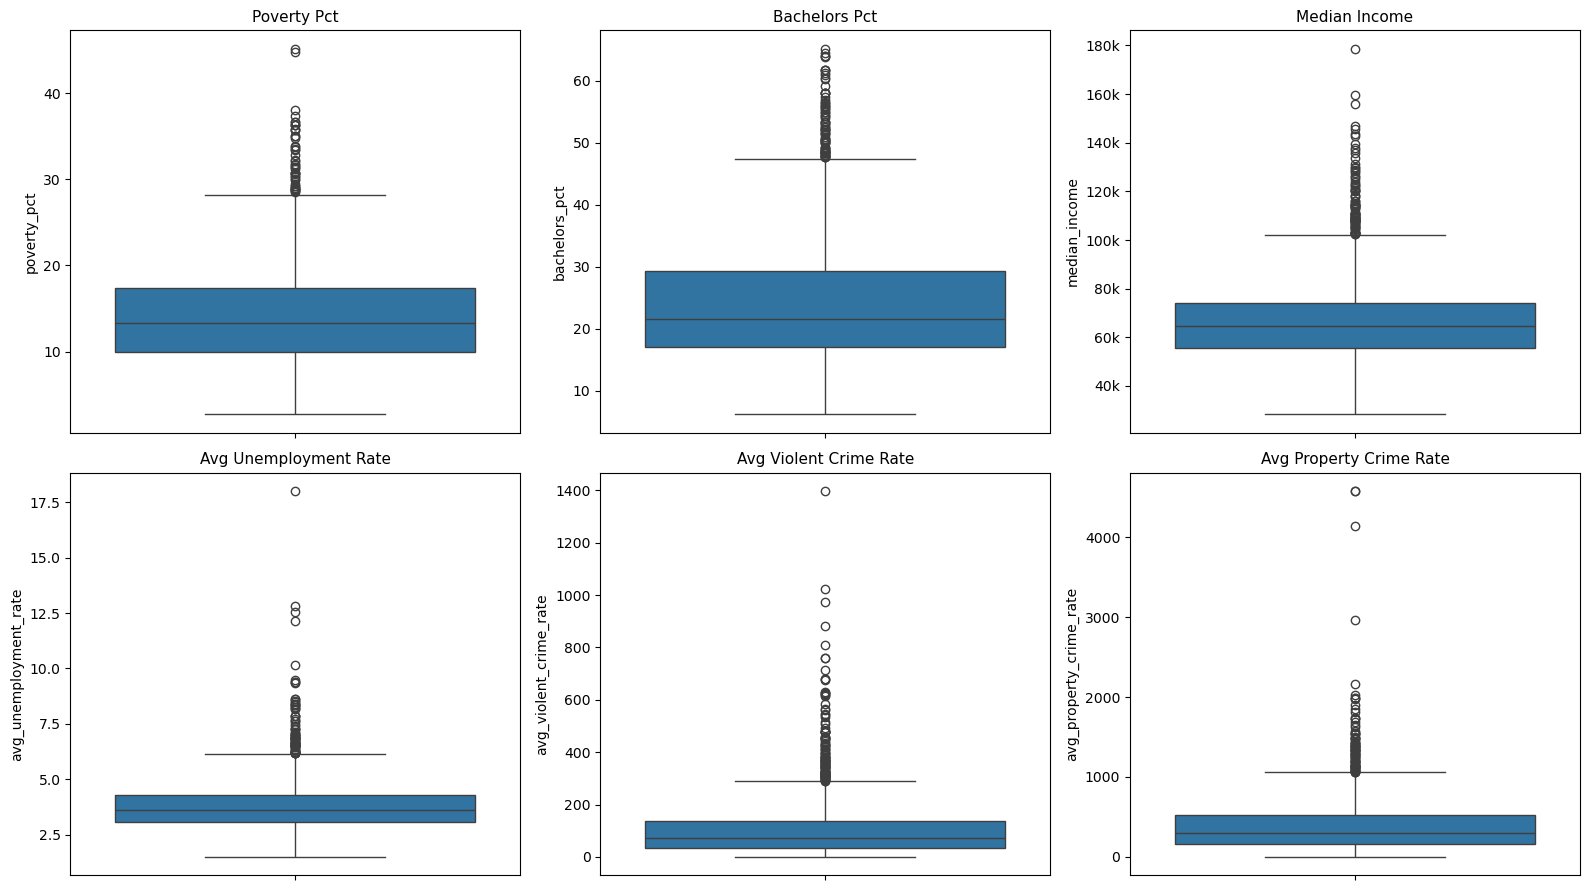

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flatten(), analysis_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col.replace("_", " ").title(), fontsize=11)

    # Format median income axis
    if col == "median_income":
        ax.yaxis.set_major_formatter(
            FuncFormatter(lambda x, pos: f"{int(x/1000)}k")
        )

plt.tight_layout()
plt.show()

The boxplots confirm the presence of several high-value observations, particularly for the crime rate variables. These counties were reviewed and determined to represent legitimate observations rather than data entry errors. Because the objective of this project is to analyze real county-level variation, these observations were retained unless they represented extremely small population counties removed during data preparation.

### 3.3 Scatterplots

Scatterplots were created to visually examine the relationships between each socioeconomic variable and both violent crime and property crime rates. Regression trend lines were included to provide an initial indication of the direction and strength of each relationship before calculating formal statistical measures.

#### 3.3.1 Violent crime scatterplots

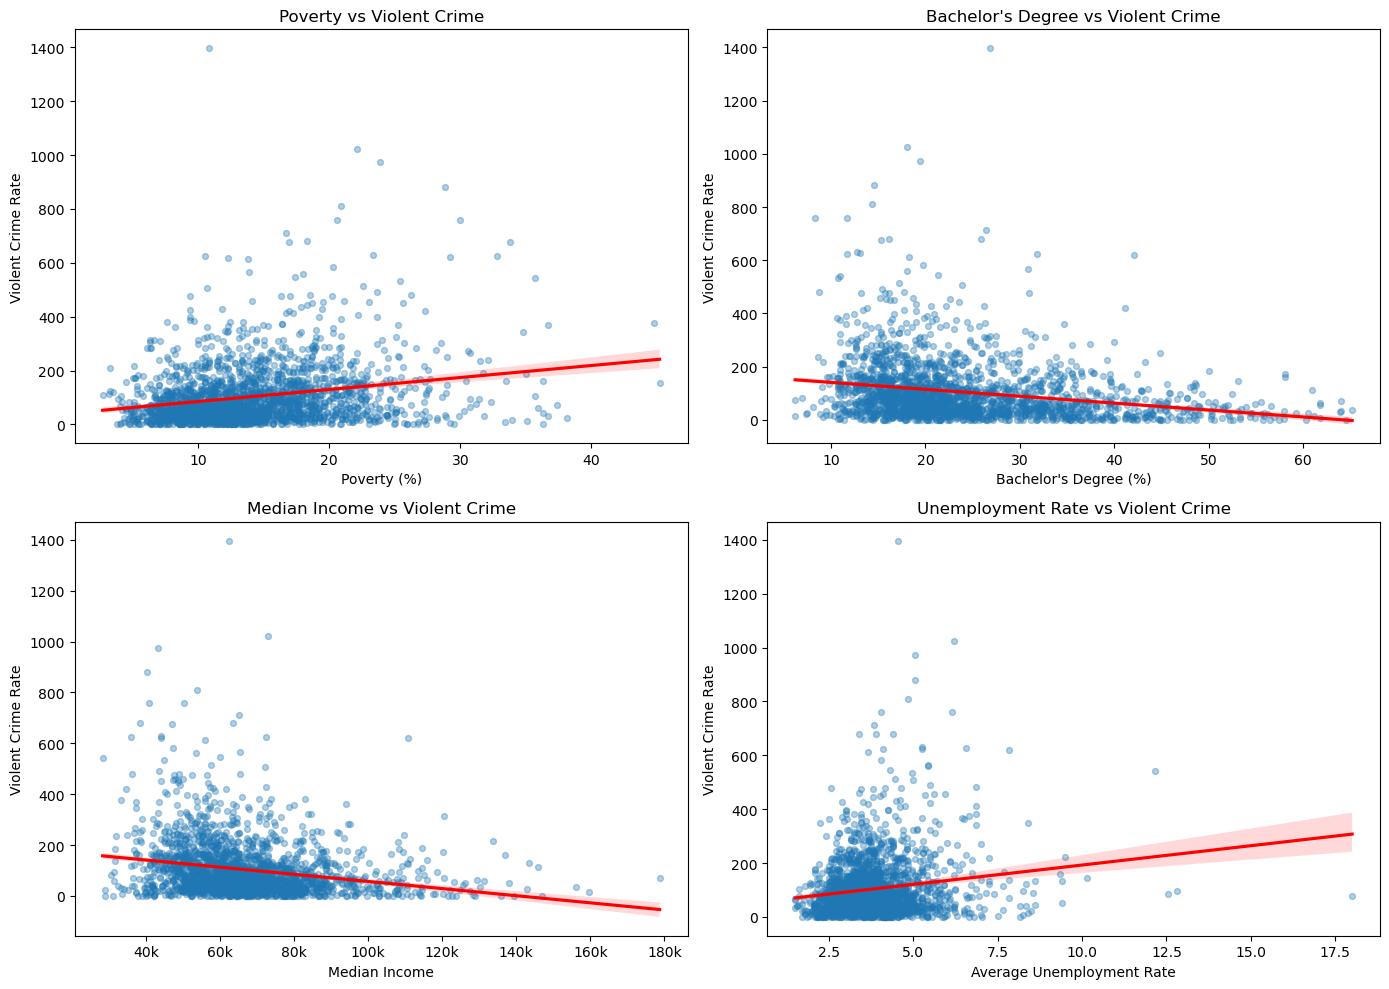

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

violent_pairs = [
    ("poverty_pct", "Poverty", "Poverty (%)"),
    ("bachelors_pct", "Bachelor's Degree", "Bachelor's Degree (%)"),
    ("median_income", "Median Income", "Median Income"),
    ("avg_unemployment_rate", "Unemployment Rate", "Average Unemployment Rate")
]

for ax, (x_col, title_label, axis_label) in zip(axes.flatten(), violent_pairs):

    sns.regplot(
        data=df,
        x=x_col,
        y="avg_violent_crime_rate",
        ax=ax,
        scatter_kws={"alpha":0.35, "s":18},
        line_kws={"color":"red"}
    )

    ax.set_title(f"{title_label} vs Violent Crime")
    ax.set_xlabel(axis_label)
    ax.set_ylabel("Violent Crime Rate")

    if x_col == "median_income":
        ax.xaxis.set_major_formatter(
            FuncFormatter(lambda x, pos: f"{int(x/1000)}k")
        )
        
plt.tight_layout()
plt.show()

The violent crime scatterplots suggest positive relationships between violent crime and both poverty and unemployment, while higher educational attainment and median household income appear to be associated with lower violent crime rates. Although considerable variation exists, the regression trend lines indicate generally consistent linear relationships suitable for further statistical analysis.

#### 3.3.2 Property crime scatterplots

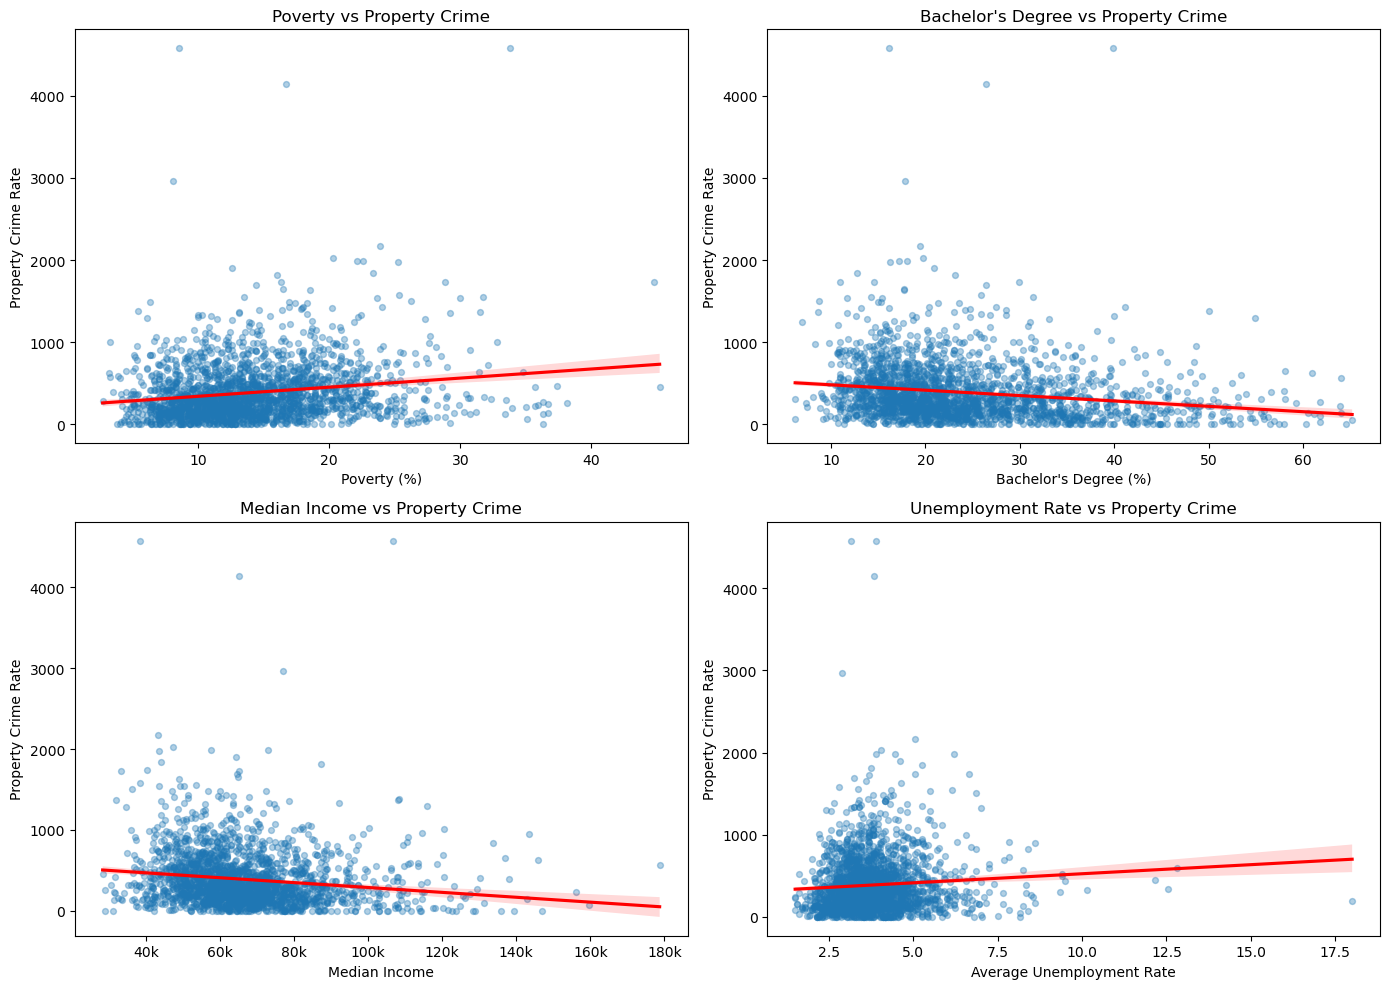

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

property_pairs = [
    ("poverty_pct", "Poverty", "Poverty (%)"),
    ("bachelors_pct", "Bachelor's Degree", "Bachelor's Degree (%)"),
    ("median_income", "Median Income", "Median Income"),
    ("avg_unemployment_rate", "Unemployment Rate", "Average Unemployment Rate")
]

for ax, (x_col, title_label, axis_label) in zip(axes.flatten(), property_pairs):

    sns.regplot(
        data=df,
        x=x_col,
        y="avg_property_crime_rate",
        ax=ax,
        scatter_kws={"alpha":0.35, "s":18},
        line_kws={"color":"red"}
    )

    ax.set_title(f"{title_label} vs Property Crime")
    ax.set_xlabel(axis_label)
    ax.set_ylabel("Property Crime Rate")

    if x_col == "median_income":
        ax.xaxis.set_major_formatter(
            FuncFormatter(lambda x, pos: f"{int(x/1000)}k")
        )

plt.tight_layout()
plt.show()

The property crime scatterplots show similar overall patterns, although the relationships appear weaker than those observed for violent crime. Poverty generally exhibits a positive relationship with property crime, while higher levels of educational attainment appear to be associated with lower property crime rates. These visual observations are evaluated more formally using Pearson correlation analysis in the following section.

## 4. Correlation Analysis

Pearson correlation analysis was performed to quantify the strength and direction of the linear relationship between each socioeconomic variable and the two crime rate variables. Unlike scatterplots, which provide a visual assessment of these relationships, Pearson correlation produces a numerical measure of association and corresponding p-value for statistical significance.

### 4.1 Correlation Matrix

The correlation matrix below summarizes the pairwise correlations among all variables included in the analysis. This visualization was reviewed to identify general relationship patterns and to evaluate whether any predictor variables exhibited correlations that might indicate multicollinearity.

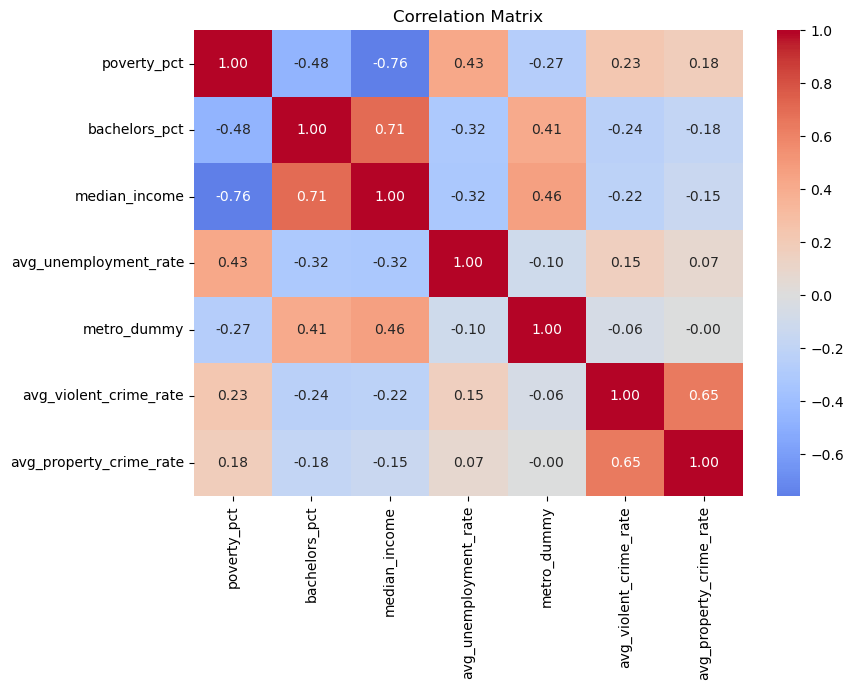

In [27]:
corr_cols = [
    "poverty_pct",
    "bachelors_pct",
    "median_income",
    "avg_unemployment_rate",
    "metro_dummy",
    "avg_violent_crime_rate",
    "avg_property_crime_rate"
]

corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

The correlation matrix indicates that several socioeconomic variables are moderately correlated with one another, which is expected given the relationships among income, education, and poverty. However, none of the observed correlations were sufficiently strong to suggest severe multicollinearity. The matrix also indicates that violent crime generally exhibits stronger associations with the socioeconomic variables than property crime.

### 4.2 Pearson Correlation Analysis

In [30]:
# Pearson correlation coefficients and p-values

predictors = [
    "poverty_pct",
    "bachelors_pct",
    "median_income",
    "avg_unemployment_rate",
    "metro_dummy"
]

targets = {
    "avg_violent_crime_rate": "Violent Crime",
    "avg_property_crime_rate": "Property Crime"
}

pearson_results = []

for predictor in predictors:
    row = {
        "predictor": predictor
    }

    for target_col, target_name in targets.items():
        r, p = stats.pearsonr(df[predictor], df[target_col])
        row[f"{target_name} r"] = r
        row[f"{target_name} p-value"] = p

    pearson_results.append(row)

pearson_df = pd.DataFrame(pearson_results)

pearson_df["predictor"] = pearson_df["predictor"].replace({
    "poverty_pct": "Poverty %",
    "bachelors_pct": "Bachelor's Degree %",
    "median_income": "Median Income",
    "avg_unemployment_rate": "Average Unemployment Rate",
    "metro_dummy": "Metro Status"
})

pearson_df.round(4)

,predictor,Violent Crime r,Violent Crime p-value,Property Crime r,Property Crime p-value
0,Poverty %,0.2297,0.000,0.1779,0.0000
1,Bachelor's Degree %,-0.2356,0.000,-0.1848,0.0000
2,Median Income,-0.2181,0.000,-0.1463,0.0000
3,Average Unemployment Rate,0.1548,0.000,0.0742,0.0006
4,Metro Status,-0.0639,0.003,-0.0020,0.9259


The Pearson correlation results show stronger relationships between the socioeconomic variables and violent crime rates than property crime rates. Poverty and unemployment have positive relationships with violent crime, while bachelor's degree attainment and median income have negative relationships. Property crime relationships appear weaker overall.

## 5. Multiple Linear Regression

While Pearson correlation measures the relationship between two variables individually, multiple linear regression evaluates the relationship between each socioeconomic variable and crime rates while controlling for the effects of the remaining variables. Separate regression models were developed for violent crime rates and property crime rates to determine whether different socioeconomic factors were associated with each crime category.

### 5.1 Violent Crime Model

A multiple linear regression model was developed to evaluate the combined relationship between the selected socioeconomic variables and county-level violent crime rates. Regression coefficients indicate the direction and magnitude of each relationship after controlling for the other variables in the model, while p-values were used to determine statistical significance using an alpha level of 0.05.

In [34]:
predictors = [
    "poverty_pct",
    "bachelors_pct",
    "median_income",
    "avg_unemployment_rate",
    "metro_dummy"
]

X = df[predictors]
X = sm.add_constant(X)

y_violent = df["avg_violent_crime_rate"]

violent_ols = sm.OLS(y_violent, X).fit()

violent_results = pd.DataFrame({
    "Predictor": predictors,
    "Coefficient": violent_ols.params[predictors],
    "p-value": violent_ols.pvalues[predictors]
}).reset_index(drop=True)

violent_results["Predictor"] = violent_results["Predictor"].replace({
    "poverty_pct": "Poverty %",
    "bachelors_pct": "Bachelor's Degree %",
    "median_income": "Median Income",
    "avg_unemployment_rate": "Average Unemployment Rate",
    "metro_dummy": "Metro Status"
})

violent_results.round(4)

,Predictor,Coefficient,p-value
0,Poverty %,2.9305,0.0000
1,Bachelor's Degree %,-2.0027,0.0000
2,Median Income,0.0001,0.6629
3,Average Unemployment Rate,3.9951,0.0645
4,Metro Status,10.3611,0.0517


The violent crime regression model indicates that higher poverty rates are associated with higher violent crime rates, while higher bachelor's degree attainment is associated with lower violent crime rates. After controlling for the other variables in the model, poverty and bachelor's degree attainment remained statistically significant predictors, whereas median income, unemployment rate, and metropolitan status were not statistically significant at the 0.05 significance level. The model explained approximately 7.7% of the variation in violent crime rates across counties.

### 5.2 Property Crime Model

A second multiple linear regression model was developed using property crime rate as the dependent variable. This model was constructed using the same predictor variables, allowing the relationships between socioeconomic characteristics and the two crime categories to be compared directly.

In [37]:
X = df[predictors]
X = sm.add_constant(X)

y_property = df["avg_property_crime_rate"]

property_ols = sm.OLS(y_property, X).fit()

property_results = pd.DataFrame({
    "Predictor": predictors,
    "Coefficient": property_ols.params[predictors],
    "p-value": property_ols.pvalues[predictors]
}).reset_index(drop=True)

property_results["Predictor"] = property_results["Predictor"].replace({
    "poverty_pct": "Poverty %",
    "bachelors_pct": "Bachelor's Degree %",
    "median_income": "Median Income",
    "avg_unemployment_rate": "Average Unemployment Rate",
    "metro_dummy": "Metro Status"
})

property_results.round(4)

,Predictor,Coefficient,p-value
0,Poverty %,11.5862,0.0000
1,Bachelor's Degree %,-7.3156,0.0000
2,Median Income,0.0019,0.0308
3,Average Unemployment Rate,-9.7717,0.1638
4,Metro Status,62.2524,0.0003


The property crime regression model indicates that poverty rate is positively associated with property crime, while bachelor's degree attainment is negatively associated. Poverty, bachelor's degree attainment, median income, and metropolitan status were statistically significant predictors, whereas unemployment rate was not statistically significant. The model explained approximately 5.5% of the variation in property crime rates across counties.

### 5.3 Regression Model Comparison

Comparing the two regression models provides insight into which socioeconomic variables were consistently associated with both violent crime and property crime, as well as how well each model explained variation in crime rates across counties.

In [40]:
ols_results = pd.DataFrame({
    "Predictor": predictors,
    "Violent Coefficient": violent_ols.params[predictors],
    "Violent p-value": violent_ols.pvalues[predictors],
    "Property Coefficient": property_ols.params[predictors],
    "Property p-value": property_ols.pvalues[predictors]
}).reset_index(drop=True)

ols_results["Predictor"] = ols_results["Predictor"].replace({
    "poverty_pct": "Poverty %",
    "bachelors_pct": "Bachelor's Degree %",
    "median_income": "Median Income",
    "avg_unemployment_rate": "Average Unemployment Rate",
    "metro_dummy": "Metro Status"
})

ols_results.round(4)

,Predictor,Violent Coefficient,Violent p-value,Property Coefficient,Property p-value
0,Poverty %,2.9305,0.0000,11.5862,0.0000
1,Bachelor's Degree %,-2.0027,0.0000,-7.3156,0.0000
2,Median Income,0.0001,0.6629,0.0019,0.0308
3,Average Unemployment Rate,3.9951,0.0645,-9.7717,0.1638
4,Metro Status,10.3611,0.0517,62.2524,0.0003


In [41]:
model_summary = pd.DataFrame({
    "Regression Model": [
        "Violent Crime",
        "Property Crime"
    ],
    "R²": [
        violent_ols.rsquared,
        property_ols.rsquared
    ],
    "Adjusted R²": [
        violent_ols.rsquared_adj,
        property_ols.rsquared_adj
    ]
})

model_summary.round(4)

,Regression Model,R²,Adjusted R²
0,Violent Crime,0.0773,0.0751
1,Property Crime,0.0553,0.0531


Comparing the two regression models shows that poverty and bachelor's degree attainment were statistically significant predictors in both models, although the overall explanatory power remained relatively low. Median income and metropolitan status were statistically significant only in the property crime model, while unemployment rate was not statistically significant in either model. Although several socioeconomic variables were associated with crime rates, the relatively low R² values suggest that additional demographic, economic, and social factors likely contribute to county crime rates beyond those included in this analysis.

## 6. Regression Assumptions

Multiple linear regression assumes linear relationships between the predictors and the dependent variable, independent observations, and the absence of severe multicollinearity among the predictor variables. Scatterplots were reviewed to verify that the relationships between the predictors and crime rates were generally linear. A correlation matrix was also examined to identify potentially strong correlations among the independent variables. Although several predictors exhibited moderate correlations, none were considered sufficiently correlated to prevent inclusion in the regression models. The relatively large sample size (2,162 counties) also supports the stability of the regression estimates. Statistical significance for the regression models was evaluated using an alpha level of 0.05.

## 7. Key Findings

The statistical analyses identified several consistent relationships between county-level socioeconomic characteristics and crime rates. The most important findings are summarized below.

* Poverty rate was positively associated with both violent crime and property crime.
* Bachelor's degree attainment was negatively associated with both violent crime and property crime.
* Violent crime demonstrated stronger overall relationships with the selected socioeconomic variables than property crime.
* Median income was statistically significant only in the property crime regression model after controlling for the other variables.
* Unemployment rate was not statistically significant in either regression model after controlling for the remaining predictors.
* The regression models explained a relatively small proportion of the variation in county crime rates, suggesting that additional factors beyond those included in this analysis contribute to differences in crime rates.

## 8. Conclusions

This analysis examined the relationships between selected socioeconomic variables and county-level violent crime and property crime rates across the United States. Poverty and bachelor's degree attainment emerged as the most consistent predictors across both crime categories, while median income and metropolitan status demonstrated more limited relationships after controlling for the remaining variables.

Although several statistically significant relationships were identified, the regression models explained only a modest proportion of the variation in county crime rates. These findings suggest that socioeconomic conditions are associated with crime patterns, but that additional demographic, economic, and community-level factors likely contribute to differences in county crime rates.

Future research could improve these models by incorporating variables such as income inequality, policing resources, demographic characteristics, housing conditions, or measures of urbanization to better explain differences in crime rates across counties.